# What are the non-SNP new-peak blocks? — feature / structural / signal characterization

**The set.** clq0.9 **tiling** blocks where, on >=1 of the 20 climate axes (bio1-19 + pc1),
the lead (min-p) **non-SNP** (SV + small-indel) LFMM record clears per-class Bonferroni
(0.05/n) while the lead **SNP** record in that same block does **not** — SNP-absent blocks
count as SNP-not-significant (the "SNPs missed it" case, which is the whole point). ~692
unique blocks. gen9, MAF>0.05.

**Question.** Are these a *special kind of genomic region* — TE/repeat-rich, non-genic,
pericentromeric (places short-read SNP calling goes blind) — or are they scattered like the
SNP peaks? Answered against a **matched background** = every tiling block carrying a testable
non-SNP record (41,908; the 692 are a subset). Whole-genome would be the wrong denominator.

**Three pillars**
- **A — feature / TE composition:** per-block coverage by protein-coding gene, TE
  (`transposable_element` + `transposon_fragment`), TE-gene, pseudogene, ncRNA; TE-superfamily
  mix (Alias field); a genic / TE / intergenic classification.
- **B — structural context:** distance to centromere, block physical size, how many blocks are
  genuinely SNP-sparse/absent (makes the caveat quantitative), lead-SV size profile.
- **C — signal-quality overlay:** lead non-SNP MAF; which leads survive genomic-inflation (GIF)
  correction — ties the characterization to the raw-p inflation caveat.

All 692 kept, **split by recurrence**: `1-axis` (noisy tail, ~79%) vs `>=2-axis` (robust core).
Raw uncalibrated p throughout.

In [1]:
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
WZAIN = f"{GEA}/phase1_replication/results/multiaxis/wza_in_clq09_tile"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
OUTDIR = f"{GEA}/phase1_replication/results/multiaxis"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

CHROM_LEN = {"Chr1":30427671,"Chr2":19698289,"Chr3":23459830,"Chr4":18585056,"Chr5":26975502}
# TAIR10 centromere midpoints (approx CEN, bp) — standard cited positions.
CEN = {"Chr1":15_086_000,"Chr2":3_607_000,"Chr3":13_799_000,"Chr4":3_956_000,"Chr5":11_725_000}

# colours: recurrence classes and background
COL = {"1-axis":"#9DB4C0", ">=2-axis":"#1B5E20", "background":"#CED4DA"}

def block_spans_tiling(r2=0.9):
    tag=f"clq{r2}"; rows=[]
    for ci in range(1,6):
        ch=f"Chr{ci}"
        g=pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv",sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends=g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo=1 if i==0 else int(ends[i-1])+1
            hi=int(ends[i]) if i<len(g)-1 else CHROM_LEN[ch]     # cap last block at chrom length
            rows.append((f"{ch}_{i}",ch,lo,hi))
    return pd.DataFrame(rows,columns=["block","chrom","start","end"]).set_index("block")
SPANS = block_spans_tiling()
SPANS["len"] = SPANS.end - SPANS.start + 1
print("tiling blocks:", len(SPANS))

tiling blocks: 58376


In [2]:
# --- load TAIR10 genes+transposons GFF into per-class interval tables ---
GFF = lib.TAIR10_GENES_TE
cols = ["chrom","src","feat","start","end","score","strand","frame","attr"]
gff = pd.read_csv(GFF, sep="\t", comment="#", header=None, names=cols,
                  usecols=["chrom","feat","start","end","attr"])
gff = gff[gff.chrom.isin(CHROM_LEN)].copy()

FEATSETS = {
    "gene":        ["gene"],                                   # protein-coding (this GFF)
    "te":          ["transposable_element","transposon_fragment"],
    "te_gene":     ["transposable_element_gene"],
    "pseudogene":  ["pseudogene"],
    "ncRNA":       ["ncRNA","miRNA","tRNA","snoRNA","snRNA","rRNA"],
}
FEAT = {k: gff[gff.feat.isin(v)][["chrom","start","end"]].copy() for k,v in FEATSETS.items()}
for k,v in FEAT.items(): print(f"  {k:11s} {len(v):7d} features")

# TE superfamily from the Alias= tag on transposable_element rows (coarse, name-prefix).
te = gff[gff.feat=="transposable_element"].copy()
te["alias"] = te.attr.str.extract(r"Alias=([^;]+)")[0].fillna("")
def te_superfamily(a):
    a=a.upper()
    if "COPIA" in a: return "LTR/Copia"
    if "GYPSY" in a or "HILA" in a or a.startswith("ATLANTYS"): return "LTR/Gypsy"
    if "LINE" in a: return "LINE"
    if "SINE" in a: return "SINE"
    if "ENSPM" in a or "CACTA" in a: return "DNA/EnSpm-CACTA"
    if a.startswith("VANDAL") or "MUDR" in a or a.startswith("ATMU"): return "DNA/MuDR"
    if a.startswith("ATREP") or "HELITRON" in a: return "DNA/Helitron"
    if "HAT" in a or "POGO" in a or "MARINER" in a or "TAG1" in a: return "DNA/hAT-Tc1"
    if "HARB" in a: return "DNA/Harbinger"
    return "other/unknown"
te["superfam"] = te.alias.map(te_superfamily)
print("\nTE superfamily counts (all genome TEs):")
print(te.superfam.value_counts().to_string())

  gene          28496 features
  te            66045 features
  te_gene        3903 features
  pseudogene      924 features
  ncRNA          1379 features

TE superfamily counts (all genome TEs):
superfam
DNA/Helitron       13606
other/unknown       6876
LTR/Gypsy           3333
DNA/MuDR            2257
LTR/Copia           1553
LINE                1207
DNA/hAT-Tc1         1195
DNA/EnSpm-CACTA      941
SINE                 131
DNA/Harbinger         90


In [3]:
# --- fast interval-union coverage: covered bp of each block by a feature class ---
def _merge(s, e):
    o=np.argsort(s); s=s[o].astype(np.int64); e=e[o].astype(np.int64)
    ms=[s[0]]; me=[e[0]]
    for i in range(1,len(s)):
        if s[i] <= me[-1]+1: me[-1]=max(me[-1],e[i])
        else: ms.append(s[i]); me.append(e[i])
    return np.array(ms), np.array(me)

def _cov_upto(x, ms, me, prefix):
    x=np.asarray(x,np.int64); res=np.zeros(len(x),np.int64)
    pos=np.searchsorted(ms, x, side="right")            # intervals [0,pos) have start<=x
    m=pos>0; idx=pos[m]-1
    last=np.minimum(me[idx], x[m]) - ms[idx] + 1
    res[m]=prefix[idx] + np.maximum(last,0)
    return res

def coverage_bp(blocks, feat):
    # covered bp of each block (rows of `blocks`: chrom,start,end) by union of `feat` intervals
    out=np.zeros(len(blocks),np.int64)
    bidx=np.arange(len(blocks))
    for ch in CHROM_LEN:
        bm = blocks.chrom.values==ch
        if not bm.any(): continue
        fm = feat[feat.chrom==ch]
        if len(fm)==0: continue
        ms,me=_merge(fm.start.values, fm.end.values)
        prefix=np.concatenate([[0], np.cumsum(me-ms+1)])[:-1]   # prefix[k]=cov bp intervals 0..k-1
        bs=blocks.start.values[bm]; be=blocks.end.values[bm]
        cov=_cov_upto(be,ms,me,prefix) - _cov_upto(bs-1,ms,me,prefix)
        out[bidx[bm]]=cov
    return out

def cov_superfam(blocks):
    # per-block TE bp broken down by superfamily (returns dict superfam->bp array)
    return {sf: coverage_bp(blocks, te[te.superfam==sf][["chrom","start","end"]])
            for sf in te.superfam.unique()}
print("coverage helpers ready")

coverage helpers ready


In [4]:
# --- recompute the 692 non-SNP new-peak blocks over 20 axes (slow: loads 40 CSVs) ---
def load(cls, axis):
    f=f"{WZAIN}/lfmm_{cls}_gen9_{axis}.csv"
    if not os.path.exists(f): return None
    d=pd.read_csv(f); d=d[d.MAF>0.05].copy()
    d["nlp"]=-np.log10(d.pval.clip(lower=1e-300)); return d
def leads(d):
    d=d[d.block.notna()&(d.block!="")]; return d.loc[d.groupby("block").nlp.idxmax()]
def gif_lambda(p):
    p=np.clip(np.asarray(p,float),1e-300,1.0)
    return float(np.median(stats.chi2.isf(p,1))/stats.chi2.isf(0.5,1))

rows=[]; LAM={}
for a in AXES:
    s,c=load("snp",a),load("nonsnp",a)
    if s is None or c is None: print("missing",a); continue
    LAM[a]=gif_lambda(c.pval)                                  # per-axis genomic inflation (nonsnp)
    bs,bc=-np.log10(0.05/len(s)),-np.log10(0.05/len(c))
    ls_,lc_=leads(s),leads(c)
    m=lc_.merge(ls_[["block","nlp"]],on="block",suffixes=("","_snp"),how="left")
    m["nlp_snp"]=m["nlp_snp"].fillna(0.0)
    npk=m[(m.nlp>bc)&(m.nlp_snp<=bs)].copy()
    npk["axis"]=a; npk["bonf_c"]=bc
    rows.append(npk[["block","chrom","pos","ref_len","alt_len","MAF","nlp","nlp_snp","axis","bonf_c"]])
PK=pd.concat(rows,ignore_index=True)
PK["size"]=(PK.alt_len-PK.ref_len).abs()
# GIF-corrected significance of each (block,axis) lead
PK["lam"]=PK["axis"].map(LAM)
PK["nlp_gif"]=-np.log10(np.clip(stats.chi2.sf(stats.chi2.isf(10**(-PK.nlp),1)/PK.lam,1),1e-300,1))
PK["survive_gif"]=PK.nlp_gif>PK.bonf_c
print(f"(block,axis) new peaks: {len(PK)} | unique blocks: {PK.block.nunique()}")
print("per-axis GIF lambda (nonsnp): min %.2f  median %.2f  max %.2f"%(min(LAM.values()),np.median(list(LAM.values())),max(LAM.values())))

(block,axis) new peaks: 903 | unique blocks: 692
per-axis GIF lambda (nonsnp): min 0.97  median 1.72  max 2.68


In [5]:
# --- collapse to one row per block; attach recurrence, best signal, SNP presence/density ---
# variant-density + SNP presence from bio1 (block membership is axis-invariant)
snp_b=load("snp","bio1"); nsnp_b=load("nonsnp","bio1")
n_snp   = snp_b.groupby("block").size().rename("n_snp")
n_nonsnp= nsnp_b.groupby("block").size().rename("n_nonsnp")
snp_blocks=set(snp_b.block.unique())
BG_blocks = sorted(nsnp_b.block.dropna().unique())             # matched background: 41,908

g=PK.sort_values("nlp",ascending=False)
best=g.drop_duplicates("block").set_index("block")
FG=pd.DataFrame(index=sorted(PK.block.unique()))
FG["n_axes"]=PK.groupby("block")["axis"].nunique()
FG["best_axis"]=best["axis"]; FG["best_nlp"]=best.nlp
FG["lead_size"]=best["size"]; FG["lead_MAF"]=best.MAF; FG["lead_pos"]=best.pos
FG["any_survive_gif"]=PK.groupby("block").survive_gif.any()
FG["recur"]=np.where(FG.n_axes>=2,">=2-axis","1-axis")
FG=FG.join(n_snp).join(n_nonsnp)
FG["n_snp"]=FG.n_snp.fillna(0).astype(int); FG["n_nonsnp"]=FG.n_nonsnp.fillna(0).astype(int)
FG["snp_present"]=FG.index.isin(snp_blocks)
FG=FG.join(SPANS[["chrom","start","end","len"]])
FG["dist_cen"]=FG.apply(lambda r:abs((r.start+r.end)/2 - CEN[r.chrom]),axis=1)
print("foreground blocks:",len(FG))
print(FG.recur.value_counts().to_string())
print("SNP-absent blocks:",int((~FG.snp_present).sum()),f"({100*(~FG.snp_present).mean():.0f}%)")
display(FG.head())

foreground blocks: 692
recur
1-axis      545
>=2-axis    147
SNP-absent blocks: 0 (0%)


,n_axes,best_axis,best_nlp,lead_size,lead_MAF,lead_pos,any_survive_gif,recur,n_snp,n_nonsnp,snp_present,chrom,start,end,len,dist_cen
Chr1_0,1,bio15,7.271522,20,0.074982,4308,False,1-axis,69,64,True,Chr1,1,6063,6063,15082968.0
Chr1_10112,1,bio15,7.331939,0,0.059685,21693330,False,1-axis,170,67,True,Chr1,21691929,21693650,1722,6606789.5
Chr1_1015,1,bio15,8.033977,3,0.074697,1963456,False,1-axis,7,3,True,Chr1,1962085,1963192,1108,13123361.5
Chr1_10184,2,bio4,7.752649,1,0.141019,21939211,False,>=2-axis,20,5,True,Chr1,21938668,21939292,625,6852980.0
Chr1_10206,1,bio15,10.768692,1,0.075552,21962181,False,1-axis,68,56,True,Chr1,21959672,21962513,2842,6875092.5


In [6]:
# --- feature coverage for foreground AND background; classify each block ---
BG=SPANS.loc[[b for b in BG_blocks if b in SPANS.index]].reset_index()[["block","chrom","start","end","len"]]
def add_cov(df):
    df=df.copy()
    for k in FEATSETS:
        df[f"cov_{k}"]=coverage_bp(df, FEAT[k])
    L=df["len"].values
    for k in FEATSETS: df[f"f_{k}"]=df[f"cov_{k}"]/L
    # TE-any = UNION of TE + TE-gene bp (not sum of fractions, which double-counts overlaps)
    df["f_te_any"]=coverage_bp(df, pd.concat([FEAT["te"],FEAT["te_gene"]]))/L
    df["f_intergenic"]=1-np.clip(df["f_gene"]+df["f_te_any"]+df["f_pseudogene"]+df["f_ncRNA"],0,1)
    def klass(r):
        if r.f_te_any>=0.5: return "TE"
        if r.f_gene>=0.5:   return "genic"
        if r.f_te_any>=0.2: return "TE-mixed"
        if r.f_gene>=0.2:   return "genic-mixed"
        return "intergenic"
    df["klass"]=df.apply(klass,axis=1)
    return df
FGc=add_cov(FG.reset_index().rename(columns={"index":"block"}))
BGc=add_cov(BG)
FGc["recur"]=FGc.block.map(FG.recur)
FGc.to_csv(f"{OUTDIR}/nonsnp_block_characterization.csv",index=False)
print("wrote nonsnp_block_characterization.csv ;", FGc.shape)
print("\nclass composition (%):")
comp=pd.concat([
    FGc[FGc.recur=="1-axis"].klass.value_counts(normalize=True).rename("FG 1-axis"),
    FGc[FGc.recur==">=2-axis"].klass.value_counts(normalize=True).rename("FG >=2-axis"),
    BGc.klass.value_counts(normalize=True).rename("background"),
],axis=1).fillna(0)*100
print(comp.round(1).to_string())

wrote nonsnp_block_characterization.csv ; (692, 30)

class composition (%):
             FG 1-axis  FG >=2-axis  background
klass                                          
genic             38.9         32.7        51.6
intergenic        20.6         17.7        23.6
TE                16.9         18.4         8.6
genic-mixed       11.9         19.0        10.4
TE-mixed          11.7         12.2         5.7


## Pillar A — feature / TE composition

Per-block coverage fractions (foreground split by recurrence vs matched background). If the
non-SNP-only signal lives where SNP calling is blind, we expect **higher TE coverage / lower
gene coverage** in the foreground than background. **ECDFs** (not histograms) so the two
foreground classes and the background overlay cleanly; enrichment by Mann-Whitney (coverage
fraction) + Fisher (block overlaps feature yes/no). Right: TE-superfamily bp mix; far right:
genic/TE/intergenic class shares.

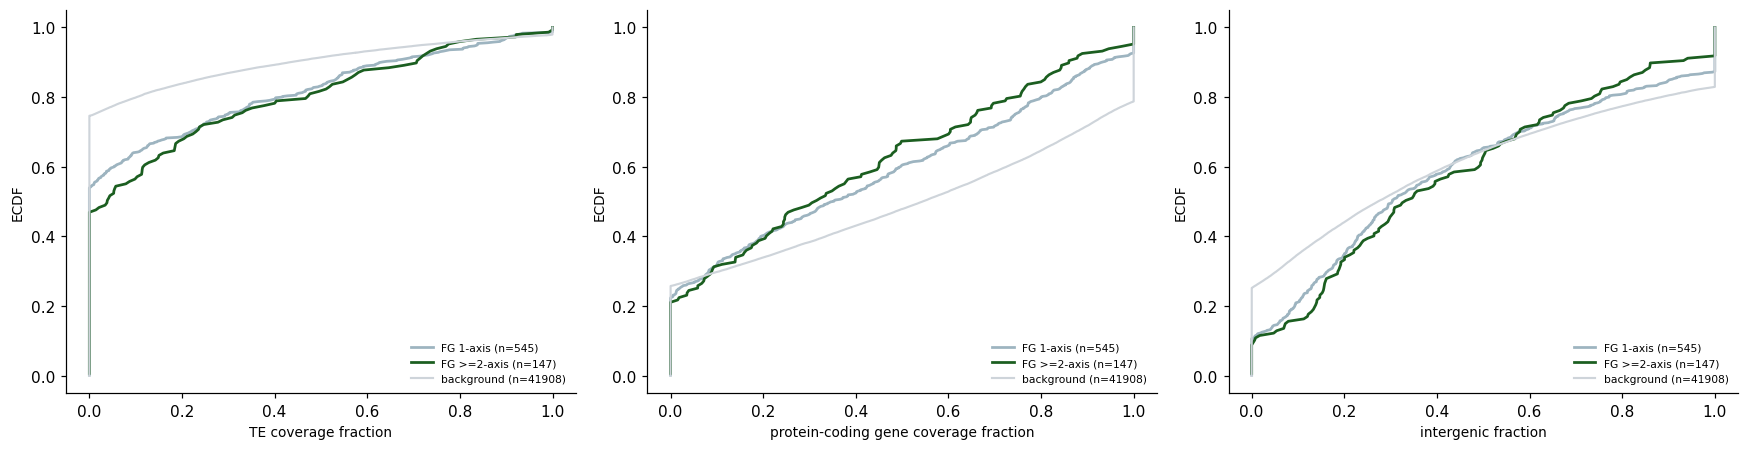

enrichment (foreground vs background; MWU alt=greater on fraction, Fisher on overlap y/n):


              fg_med  bg_med   mwu_p  fg_ovl  bg_ovl  fisher_or  fisher_p
key                                                                      
f_te_any      0.0000  0.0000  0.0000  0.4754  0.2537     2.6668    0.0000
f_gene        0.3391  0.5437  1.0000  0.7803  0.7423     1.2332    0.0226
f_pseudogene  0.0000  0.0000  0.0000  0.0708  0.0230     3.2401    0.0000
f_ncRNA       0.0000  0.0000  0.0005  0.0491  0.0279     1.8023    0.0023
f_intergenic  0.3076  0.2723  0.0000  0.8974  0.7480     2.9464    0.0000


In [7]:
def ecdf(ax, vals, label, color, lw=1.8):
    v=np.sort(np.asarray(vals,float)); y=np.arange(1,len(v)+1)/len(v)
    ax.plot(v,y,label=f"{label} (n={len(v)})",color=color,lw=lw)

def panel_frac(ax, key, xlabel):
    for r,cc in [("1-axis",COL["1-axis"]),(">=2-axis",COL[">=2-axis"])]:
        ecdf(ax, FGc[FGc.recur==r][key], f"FG {r}", cc)
    ecdf(ax, BGc[key], "background", COL["background"], lw=1.4)
    ax.set_xlabel(xlabel,fontsize=9); ax.set_ylabel("ECDF",fontsize=9)
    ax.legend(frameon=False,fontsize=7,loc="lower right")

def enr(key):
    fg=FGc[key].values; bg=BGc[key].values
    u,p=stats.mannwhitneyu(fg,bg,alternative="greater")
    # Fisher on "overlaps feature" (frac>0)
    a=int((fg>0).sum()); b=len(fg)-a; c=int((bg>0).sum()); d=len(bg)-c
    orr,pf=stats.fisher_exact([[a,b],[c,d]])
    return dict(key=key, fg_med=np.median(fg), bg_med=np.median(bg), mwu_p=p,
                fg_ovl=a/len(fg), bg_ovl=c/len(bg), fisher_or=orr, fisher_p=pf)

fig,axs=plt.subplots(1,3,figsize=(16,4.2))
panel_frac(axs[0],"f_te_any","TE coverage fraction")
panel_frac(axs[1],"f_gene","protein-coding gene coverage fraction")
panel_frac(axs[2],"f_intergenic","intergenic fraction")
fig.tight_layout(); plt.show()

print("enrichment (foreground vs background; MWU alt=greater on fraction, Fisher on overlap y/n):")
print(pd.DataFrame([enr("f_te_any"),enr("f_gene"),enr("f_pseudogene"),enr("f_ncRNA"),
                    enr("f_intergenic")]).set_index("key").round(4).to_string())

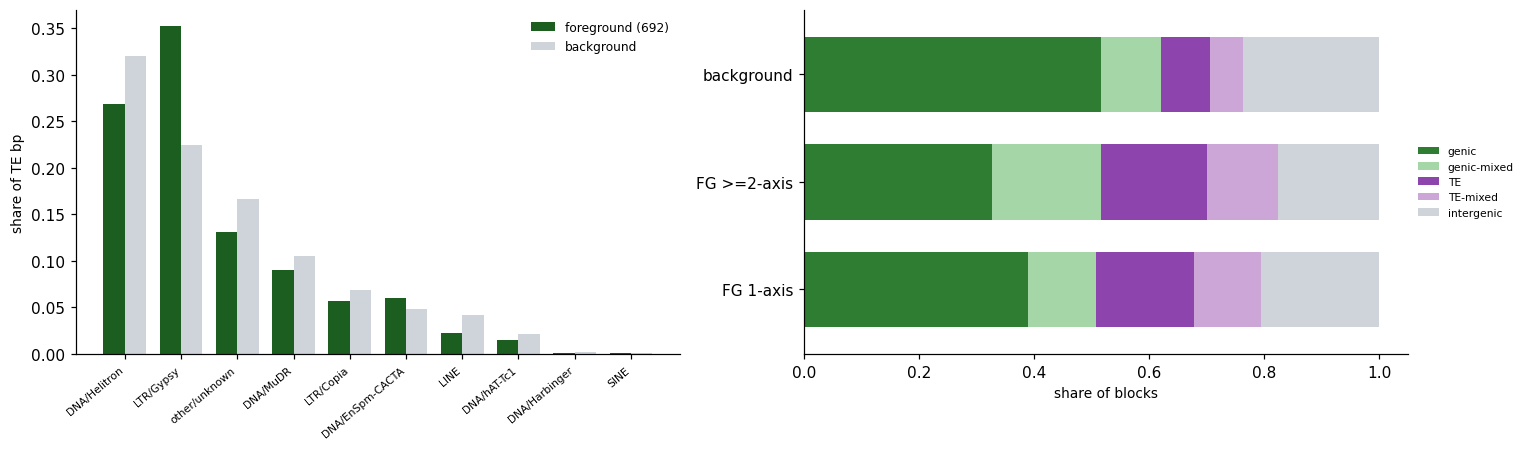

In [8]:
# TE-superfamily bp mix (foreground vs background) + class-share bars
sf_fg=cov_superfam(FGc); sf_bg=cov_superfam(BGc)
def sf_frac(covd):
    tot=max(sum(v.sum() for v in covd.values()),1)
    return {sf: covd[sf].sum()/tot for sf in covd}
FGsf=sf_frac(sf_fg); BGsf=sf_frac(sf_bg)
order=[k for k,_ in sorted(BGsf.items(),key=lambda kv:-kv[1])]
fig,axs=plt.subplots(1,2,figsize=(14,4.2))
x=np.arange(len(order)); w=0.38
axs[0].bar(x-w/2,[FGsf[k] for k in order],w,label="foreground (692)",color=COL[">=2-axis"])
axs[0].bar(x+w/2,[BGsf[k] for k in order],w,label="background",color=COL["background"])
axs[0].set_xticks(x); axs[0].set_xticklabels(order,rotation=40,ha="right",fontsize=7)
axs[0].set_ylabel("share of TE bp",fontsize=9); axs[0].legend(frameon=False,fontsize=8)
# genic/TE/intergenic class shares
ks=["genic","genic-mixed","TE","TE-mixed","intergenic"]
share=pd.concat([
    FGc[FGc.recur=="1-axis"].klass.value_counts(normalize=True).rename("FG 1-axis"),
    FGc[FGc.recur==">=2-axis"].klass.value_counts(normalize=True).rename("FG >=2-axis"),
    BGc.klass.value_counts(normalize=True).rename("background")],axis=1).reindex(ks).fillna(0)
share.T.plot(kind="barh",stacked=True,ax=axs[1],
             color=["#2E7D32","#A5D6A7","#8E44AD","#CBA6D6","#CED4DA"],width=0.7)
axs[1].set_xlabel("share of blocks",fontsize=9)
axs[1].legend(frameon=False,fontsize=7,loc="center left",bbox_to_anchor=(1.0,0.5))
fig.tight_layout(); plt.show()

## Pillar B — structural context

Are the blocks pericentromeric, physically large, and SNP-sparse? **Left:** distance from
block midpoint to its chromosome's centromere (foreground vs background — a leftward shift =
pericentromeric enrichment). **Middle:** block length. **Right:** SNP density (# SNP records
per block) with the SNP-absent fraction called out — the quantitative form of the "SNPs missed
it" caveat. Below: lead-variant size (SV vs small-indel) split by recurrence.

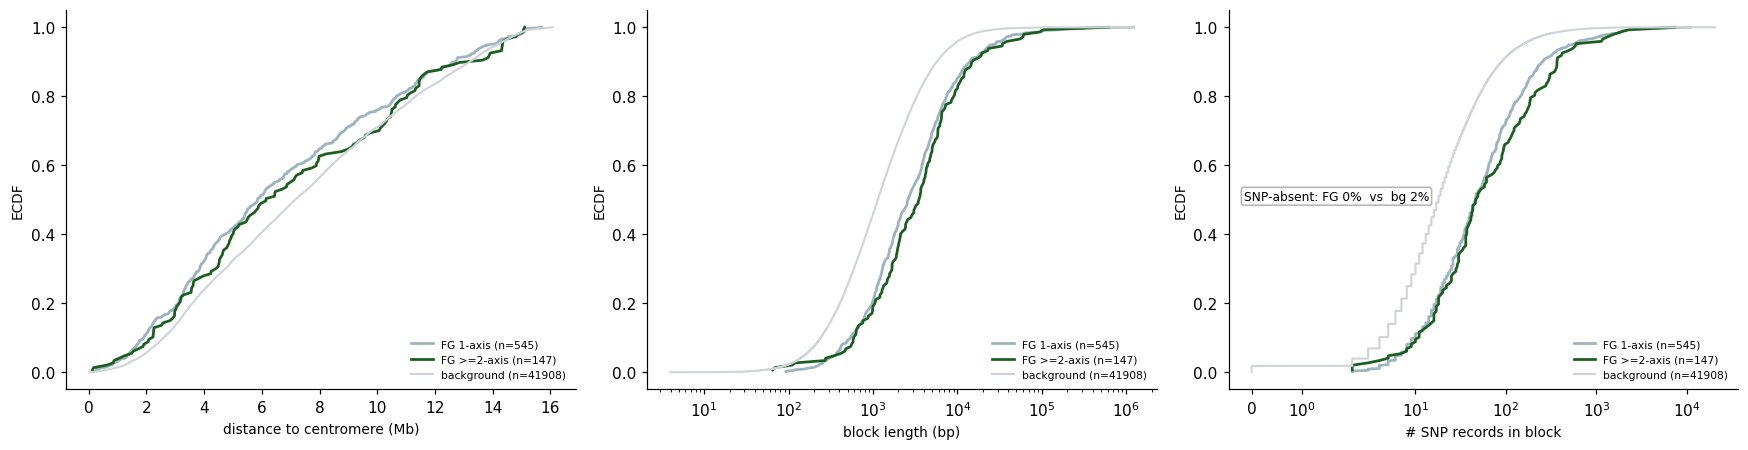

dist-to-centromere FG<bg  MWU p=2.05e-07  (FG median 5.92 Mb vs bg 7.16 Mb)
SNP-absent foreground blocks: 0/692 (0%)


In [9]:
fig,axs=plt.subplots(1,3,figsize=(16,4.2))
# distance to centromere (Mb)
for r,cc in [("1-axis",COL["1-axis"]),(">=2-axis",COL[">=2-axis"])]:
    ecdf(axs[0], FGc[FGc.recur==r].block.map(FG.dist_cen)/1e6, f"FG {r}", cc)
ecdf(axs[0], BG.apply(lambda r:abs((r.start+r.end)/2-CEN[r.chrom]),axis=1)/1e6,"background",COL["background"],1.4)
axs[0].set_xlabel("distance to centromere (Mb)",fontsize=9); axs[0].set_ylabel("ECDF",fontsize=9)
axs[0].legend(frameon=False,fontsize=7,loc="lower right")
# block length (log)
for r,cc in [("1-axis",COL["1-axis"]),(">=2-axis",COL[">=2-axis"])]:
    ecdf(axs[1], FGc[FGc.recur==r].len, f"FG {r}", cc)
ecdf(axs[1], BGc.len,"background",COL["background"],1.4)
axs[1].set_xscale("log"); axs[1].set_xlabel("block length (bp)",fontsize=9); axs[1].set_ylabel("ECDF",fontsize=9)
axs[1].legend(frameon=False,fontsize=7,loc="lower right")
# SNP density
for r,cc in [("1-axis",COL["1-axis"]),(">=2-axis",COL[">=2-axis"])]:
    ecdf(axs[2], FG[FG.recur==r].n_snp, f"FG {r}", cc)
ecdf(axs[2], n_snp.reindex(BG_blocks).fillna(0),"background",COL["background"],1.4)
axs[2].set_xscale("symlog"); axs[2].set_xlabel("# SNP records in block",fontsize=9); axs[2].set_ylabel("ECDF",fontsize=9)
axs[2].legend(frameon=False,fontsize=7,loc="lower right")
axs[2].annotate(f"SNP-absent: FG {100*(~FG.snp_present).mean():.0f}%  vs  bg "
                f"{100*(n_snp.reindex(BG_blocks).isna()).mean():.0f}%",
                xy=(0.03,0.5),xycoords="axes fraction",fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="0.7"))
fig.tight_layout(); plt.show()

# stats
d1=stats.mannwhitneyu(FG.dist_cen, BG.apply(lambda r:abs((r.start+r.end)/2-CEN[r.chrom]),axis=1),alternative="less")
print(f"dist-to-centromere FG<bg  MWU p={d1.pvalue:.2e}  (FG median {FG.dist_cen.median()/1e6:.2f} Mb vs bg {(BG.apply(lambda r:abs((r.start+r.end)/2-CEN[r.chrom]),axis=1)).median()/1e6:.2f} Mb)")
sA=int((~FG.snp_present).sum()); print(f"SNP-absent foreground blocks: {sA}/{len(FG)} ({100*sA/len(FG):.0f}%)")

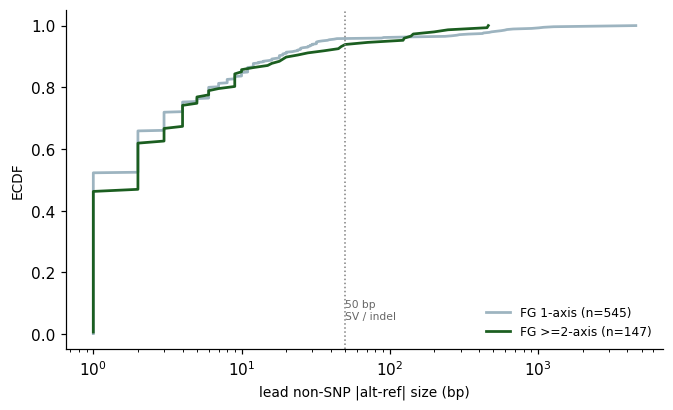

lead is SV (>50bp): FG 1-axis 4%  vs  >=2-axis 6%


In [10]:
# lead-variant size split by recurrence (SV >50 bp vs small-indel <=50 bp)
fig,ax=plt.subplots(figsize=(7,4))
for r,cc in [("1-axis",COL["1-axis"]),(">=2-axis",COL[">=2-axis"])]:
    ecdf(ax, FG[FG.recur==r].lead_size.clip(lower=1), f"FG {r}", cc)
ax.axvline(50,ls=":",c="0.5",lw=1); ax.set_xscale("log")
ax.annotate("50 bp\nSV / indel",xy=(50,0.05),fontsize=7,color="0.4",ha="left")
ax.set_xlabel("lead non-SNP |alt-ref| size (bp)",fontsize=9); ax.set_ylabel("ECDF",fontsize=9)
ax.legend(frameon=False,fontsize=8,loc="lower right")
plt.show()
print("lead is SV (>50bp): FG 1-axis %.0f%%  vs  >=2-axis %.0f%%"%(
    100*(FG[FG.recur=="1-axis"].lead_size>50).mean(),
    100*(FG[FG.recur==">=2-axis"].lead_size>50).mean()))

## Pillar C — signal-quality overlay (the calibration caveat, quantified)

These are **raw, uncalibrated** LFMM p. Two suspect-signal axes: **(left)** lead non-SNP MAF —
low-MAF leads are the fragile ones; **(right)** genomic-inflation survival — deflate each lead's
chi2 by its axis' GIF lambda and re-test at that axis' Bonferroni. The count of the 692 whose
lead survives GIF is the honest first-pass on how much of this list is inflation vs signal
(cf. the `gif_manhattan_snp_vs_nonsnp_lfmm_tile.ipynb` twin).

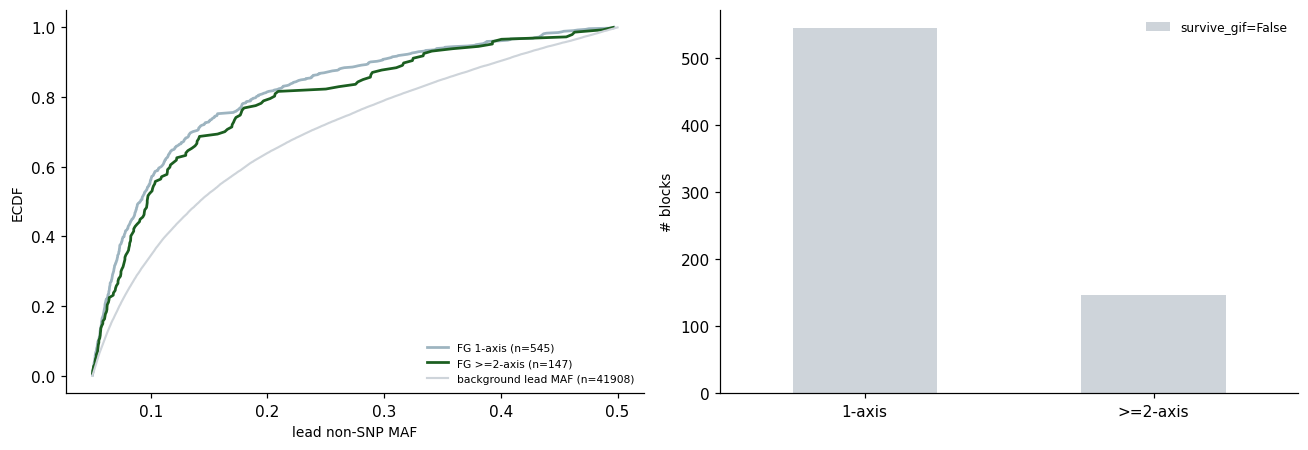

blocks whose lead survives GIF correction: 0/692 (0%)
          sum  mean
recur              
1-axis      0   0.0
>=2-axis    0   0.0


In [11]:
fig,axs=plt.subplots(1,2,figsize=(12,4.2))
bg_lead=nsnp_b.loc[nsnp_b.groupby("block")["pval"].idxmin(),["block","MAF"]].set_index("block")
for r,cc in [("1-axis",COL["1-axis"]),(">=2-axis",COL[">=2-axis"])]:
    ecdf(axs[0], FG[FG.recur==r].lead_MAF, f"FG {r}", cc)
ecdf(axs[0], bg_lead.MAF.reindex(BG_blocks).dropna(),"background lead MAF",COL["background"],1.4)
axs[0].set_xlabel("lead non-SNP MAF",fontsize=9); axs[0].set_ylabel("ECDF",fontsize=9)
axs[0].legend(frameon=False,fontsize=7,loc="lower right")

# GIF survival bars by recurrence
surv=pd.crosstab(FG.recur, FG.any_survive_gif)
surv.columns=[f"survive_gif={c}" for c in surv.columns]
surv.plot(kind="bar",stacked=True,ax=axs[1],color=["#CED4DA","#1B5E20"])
axs[1].set_ylabel("# blocks",fontsize=9); axs[1].set_xlabel("")
axs[1].tick_params(axis="x",rotation=0); axs[1].legend(frameon=False,fontsize=8)
fig.tight_layout(); plt.show()

nsurv=int(FG.any_survive_gif.sum())
print(f"blocks whose lead survives GIF correction: {nsurv}/{len(FG)} ({100*nsurv/len(FG):.0f}%)")
print(FG.groupby("recur").any_survive_gif.agg(["sum","mean"]).round(3).to_string())

## Summary table + master CSV

`nonsnp_block_characterization.csv` — one row per block: chrom, span, len, recurrence class,
best axis/p, lead size/MAF, SNP presence & density, distance-to-centromere, per-class coverage
fractions, genic/TE/intergenic class, and GIF survival. Top rows below by recurrence then
signal.

In [12]:
cols=["block","chrom","start","end","len","recur","n_axes","best_axis","best_nlp",
      "lead_size","lead_MAF","snp_present","n_snp","n_nonsnp","dist_cen",
      "f_gene","f_te_any","f_pseudogene","f_intergenic","klass","any_survive_gif"]
# FGc already carries every column (block stats + coverage); just select + sort.
show=FGc[[c for c in cols if c in FGc.columns]].sort_values(
    ["recur","best_nlp"],ascending=[True,False])
display(show.head(40))
print("full table:", f"{OUTDIR}/nonsnp_block_characterization.csv")

,block,chrom,start,end,len,recur,n_axes,best_axis,best_nlp,lead_size,...,snp_present,n_snp,n_nonsnp,dist_cen,f_gene,f_te_any,f_pseudogene,f_intergenic,klass,any_survive_gif
319,Chr3_4363,Chr3,8713991,8718606,4616,1-axis,1,bio15,13.223576,1,...,True,25,21,5082701.5,0.644714,0.000000,0.000000,0.355286,genic,False
474,Chr4_7809,Chr4,15673534,15674020,487,1-axis,1,bio15,12.895441,1,...,True,6,5,11717777.0,0.000000,0.000000,0.000000,1.000000,intergenic,False
583,Chr5_2736,Chr5,5654499,5658552,4054,1-axis,1,bio15,12.742852,1,...,True,34,23,6068474.5,0.665022,0.000000,0.000000,0.334978,genic,False
511,Chr5_11748,Chr5,22799566,22804144,4579,1-axis,1,bio15,12.491333,19,...,True,58,28,11076855.0,0.863944,0.000000,0.000000,0.136056,genic,False
518,Chr5_11945,Chr5,23111284,23118211,6928,1-axis,1,bio15,12.487582,1,...,True,55,20,11389747.5,0.906467,0.000000,0.000000,0.093533,genic,False
399,Chr4_1899,Chr4,5439908,5445968,6061,1-axis,1,bio15,12.328056,3,...,True,235,102,1486938.0,0.267943,0.510312,0.000000,0.221746,TE,False
472,Chr4_7541,Chr4,14785438,14798727,13290,1-axis,1,bio15,12.328056,1,...,True,63,52,10836082.5,0.438901,0.000000,0.000000,0.561099,genic-mixed,False
289,Chr3_3171,Chr3,6494117,6495921,1805,1-axis,1,bio15,12.301912,33,...,True,67,48,7303981.0,0.000000,0.000000,0.000000,1.000000,intergenic,False
293,Chr3_3216,Chr3,6618603,6619151,549,1-axis,1,bio15,11.990523,8,...,True,5,4,7180123.0,0.000000,0.000000,0.000000,1.000000,intergenic,False
654,Chr5_6435,Chr5,15027124,15029112,1989,1-axis,1,bio15,11.974395,1,...,True,88,52,3303118.0,0.000000,0.246858,0.000000,0.753142,TE-mixed,False


full table: /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/results/multiaxis/nonsnp_block_characterization.csv


## Conclusions — what are these blocks?

A **structurally distinct region class**, but **not a set of calibration-robust adaptive loci**:

1. **The SNP-vs-non-SNP contrast is genuine, not SNP-absence.** 0/692 blocks lack SNPs — every
   one carries SNP records that are simply *not significant* while a non-SNP is. These blocks are
   in fact SNP-**richer** and physically **larger** than background, so the "SNPs missed it" caveat
   from the gene-level view does not bite at block level.
2. **~2x TE-enriched, pseudogene-enriched, gene-depleted** — TE-overlap 48% vs 25% (Fisher OR 2.7),
   pseudogene OR 3.2, genic class 33-39% vs 52%. TE-superfamily mix mirrors the genome (Helitron /
   Gypsy dominant): no single element drives it.
3. **Pericentromere-leaning** — median 5.9 vs 7.2 Mb to the centromere (MWU p=2e-7).
4. **A small-indel story, not SV** — ~95% of leads are <=50 bp indels; only 4-6% are SVs (>50 bp).
5. **The signal does not survive genomic-inflation correction** — per-axis lambda median 1.72, and
   **0/692 leads survive GIF** at Bonferroni; leads are low-MAF (~0.11).

**Read.** The non-SNP-only peaks concentrate in exactly the compartment where indels are dense *and*
LFMM inflation is worst (TE-rich, pericentromeric, low-MAF). Pillars A-B tell us *where* such signals
arise; pillar C shows the raw significance is inflation-driven — consistent with the WZA honest-null
collapse (`../wza_investigation/`, block-calibration memory). Downstream claims need the calibrated
(GIF / honest-null) threshold, not raw Bonferroni.